In [1]:
import os 
import sys 
import re 
import yaml
import inspect 
import numpy as np 
import pandas as pd
import xarray as xr
from collections import defaultdict
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap

from scipy.io import savemat
from collections import OrderedDict
import matplotlib.colors as mcolors


In [2]:
#Plot formatting
mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['axes.titlesize'] = 28
mpl.rcParams['axes.xmargin'] = 0

# Set the font family to 'serif'
mpl.rcParams['font.family'] = 'serif'
# Specify preferred serif font (Computer Modern Roman is 'cmr10')
mpl.rcParams['font.serif'] = 'Lato' 
# Optionally, configure mathtext to use Computer Modern fonts as well
mpl.rcParams['mathtext.fontset'] = 'cm'
# Ensure minus signs are rendered correctly with CM fonts
mpl.rcParams['axes.unicode_minus'] = False

# Main datapaths
dirpath = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/'
#define path for Hawthorne data directory
savepath= dirpath + 'Merge_scripts/'
plots_savepath= dirpath + 'Merge_scripts/plots/'

In [3]:
#Get names of variables needed from Mobile Lab and UDAQ dataset
mappings_filepath = dirpath + 'Hawthorne_data/mappings/manually_edited/UDAQ_Hawthorne_CRACMM_GEOSCHEM_CB6r5h_mapped_updated_11172025.csv'
df_mapping_parameters = pd.read_csv(mappings_filepath)
df_mapping_parameters = df_mapping_parameters.drop([0]) #drop Total NMVOCs

usos_vars = [str(spec) for spec in df_mapping_parameters['USOS Mapping'].dropna()]
usos_vars.append('time_local')
print(usos_vars)

['Ethane_WAS', 'Ethene_WAS', 'Propane_WAS', 'Propene_WAS', 'Ethyne_WAS', 'nButane_WAS', 'iButane_WAS', 't2Butene_WAS', 'c2Butene_WAS', 'x13_Butadiene_WAS', 'nPentane_WAS', 'iPentane_WAS', 'x1_Pentene_WAS', 't2Pentene_WAS', 'c2Pentene_WAS', 'x3_MethylPentane_WAS', 'nHexane_WAS', 'nHeptane_WAS', 'nOctane_WAS', 'nNonane_WAS', 'nDecane_WAS', 'CycloPentane_WAS', 'Isoprene_PTR', 'x22_DiMethylButane_WAS', 'x224_TriMethylPentane_WAS', 'MethylCycloHexane_WAS', 'MethylCycloPentane_WAS', 'x1_Butene_WAS', 'x2_MethylPentane_WAS', 'HCHO_CRDS', 'm_p_Xylene_WAS', 'Benzene_PTR', 'Toluene_PTR', 'Ethyl_WAS', 'o_Xylene_WAS', 'x135_TriMethylBenzene_WAS', 'x124_TriMethylBenzene_WAS', 'nPropylBenzene_WAS', 'iPropylBenzene_WAS', 'x2_EthylToluene_WAS', 'x3_x4_EthylToluene_WAS', 'x3_x4_EthylToluene_WAS', 'Styrene_PTR', 'x123_TriMethylBenzene_WAS', 'time_local']


In [4]:
ml_data = xr.open_dataset('/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/CampaignData_and_Merges/R0/CSL_MobileLab_Parked/merged/rev_1hr/all_CSL_MobileLab_Parked_rev1hr_iWASupdated.nc')
ml_data_vars_subset = ml_data[usos_vars]
df_ml_data = ml_data_vars_subset.to_dataframe()
df_ml_data.set_index('time_local', inplace=True)

udaq_voc_file = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/Hawthorne_data/data/hawthorne_udaq_all_vocs_hourly_timezone_carbon_number_updated.csv'
df_udaq_data = pd.read_csv(udaq_voc_file, index_col='time_local', parse_dates=True)

#Get only the data during the overlapping times
df_ml_data = df_ml_data.sort_index().loc['2024-07-15 12:00:00':'2024-08-18 18:00:00']
df_udaq_data = df_udaq_data.sort_index().loc['2024-07-15 12:00:00':'2024-08-18 18:00:00']

#Map the same species in ML and UDAQ data
mapping = dict(zip(df_mapping_parameters['USOS Mapping'], df_mapping_parameters['UDAQ_Variable']))
#print(mapping)

#remove Formaldehyde from VOC species
#print(df_ml_data)
df_ml_data = df_ml_data.drop(columns = 'HCHO_CRDS')
df_udaq_data = df_udaq_data.drop(columns ='Formaldehyde')
del mapping['HCHO_CRDS']
print(df_ml_data.columns)
print(df_udaq_data.columns)
print(mapping)

Index(['Ethane_WAS', 'Ethene_WAS', 'Propane_WAS', 'Propene_WAS', 'Ethyne_WAS',
       'nButane_WAS', 'iButane_WAS', 't2Butene_WAS', 'c2Butene_WAS',
       'x13_Butadiene_WAS', 'nPentane_WAS', 'iPentane_WAS', 'x1_Pentene_WAS',
       't2Pentene_WAS', 'c2Pentene_WAS', 'x3_MethylPentane_WAS', 'nHexane_WAS',
       'nHeptane_WAS', 'nOctane_WAS', 'nNonane_WAS', 'nDecane_WAS',
       'CycloPentane_WAS', 'Isoprene_PTR', 'x22_DiMethylButane_WAS',
       'x224_TriMethylPentane_WAS', 'MethylCycloHexane_WAS',
       'MethylCycloPentane_WAS', 'x1_Butene_WAS', 'x2_MethylPentane_WAS',
       'm_p_Xylene_WAS', 'Benzene_PTR', 'Toluene_PTR', 'Ethyl_WAS',
       'o_Xylene_WAS', 'x135_TriMethylBenzene_WAS',
       'x124_TriMethylBenzene_WAS', 'nPropylBenzene_WAS', 'iPropylBenzene_WAS',
       'x2_EthylToluene_WAS', 'x3_x4_EthylToluene_WAS', 'Styrene_PTR',
       'x123_TriMethylBenzene_WAS'],
      dtype='object')
Index(['nDodecane', 'Ethane', 'Ethylene', 'Propane', 'Propylene', 'Acetylene',
       'nButa

In [5]:
pd.set_option("display.max_rows", None)
print(df_ml_data['iPentane_WAS'])

time_local
2024-07-15 12:00:00    0.96400
2024-07-15 13:00:00        NaN
2024-07-15 14:00:00        NaN
2024-07-15 15:00:00        NaN
2024-07-15 16:00:00    0.28800
2024-07-15 17:00:00        NaN
2024-07-15 18:00:00    0.55200
2024-07-15 19:00:00        NaN
2024-07-15 20:00:00    0.11000
2024-07-15 21:00:00        NaN
2024-07-15 22:00:00    0.16000
2024-07-15 23:00:00        NaN
2024-07-16 00:00:00    0.72400
2024-07-16 01:00:00        NaN
2024-07-16 02:00:00    0.18500
2024-07-16 03:00:00        NaN
2024-07-16 04:00:00    0.19800
2024-07-16 05:00:00        NaN
2024-07-16 06:00:00    0.32100
2024-07-16 07:00:00        NaN
2024-07-16 08:00:00    0.47000
2024-07-16 09:00:00        NaN
2024-07-16 10:00:00    0.38800
2024-07-16 11:00:00        NaN
2024-07-16 12:00:00    0.30500
2024-07-16 13:00:00        NaN
2024-07-16 14:00:00    0.15900
2024-07-16 15:00:00        NaN
2024-07-16 16:00:00    0.18800
2024-07-16 17:00:00        NaN
2024-07-16 18:00:00    0.56300
2024-07-16 19:00:00        N

In [6]:
#Turn any negatives into NaNs
for spec in df_ml_data.columns:
    df_ml_data[spec] = df_ml_data[spec].mask(df_ml_data[spec] < 0, np.nan)

#Rename columns to a more common name by using the mappings
df_ml_data.columns = [
    mapping.get(col) if not pd.isna(col) else mapping.get(np.nan, col)
    for col in df_ml_data.columns
]

# Fraction of each species per hour per day
hourly_fraction = df_ml_data.div(df_ml_data.sum(axis=1), axis=0)
print(hourly_fraction)
# Average fractions across all days grouped by hour
mean_per_hour = hourly_fraction.groupby(hourly_fraction.index.hour).mean()

print(mean_per_hour)
# # Select the typical time fractions
fractions_9 = mean_per_hour.loc[9]
fractions_12 = mean_per_hour.loc[12]
fractions_15 = mean_per_hour.loc[15]
fractions_18 = mean_per_hour.loc[18]
# print(fractions_9)

                       Ethane  Ethylene   Propane  Propylene  Acetylene  \
time_local                                                                
2024-07-15 12:00:00  0.228730  0.046533  0.193328   0.012554   0.030548   
2024-07-15 13:00:00       NaN       NaN       NaN        NaN        NaN   
2024-07-15 14:00:00       NaN       NaN       NaN        NaN        NaN   
2024-07-15 15:00:00       NaN       NaN       NaN        NaN        NaN   
2024-07-15 16:00:00  0.320049  0.043467  0.093578   0.012182   0.033777   
2024-07-15 17:00:00       NaN       NaN       NaN        NaN        NaN   
2024-07-15 18:00:00  0.241957  0.030245  0.112149   0.017846   0.022355   
2024-07-15 19:00:00       NaN       NaN       NaN        NaN        NaN   
2024-07-15 20:00:00  0.233706  0.035518  0.206594   0.009458   0.026481   
2024-07-15 21:00:00       NaN       NaN       NaN        NaN        NaN   
2024-07-15 22:00:00  0.239843  0.044032  0.204617   0.011914   0.039369   
2024-07-15 23:00:00      

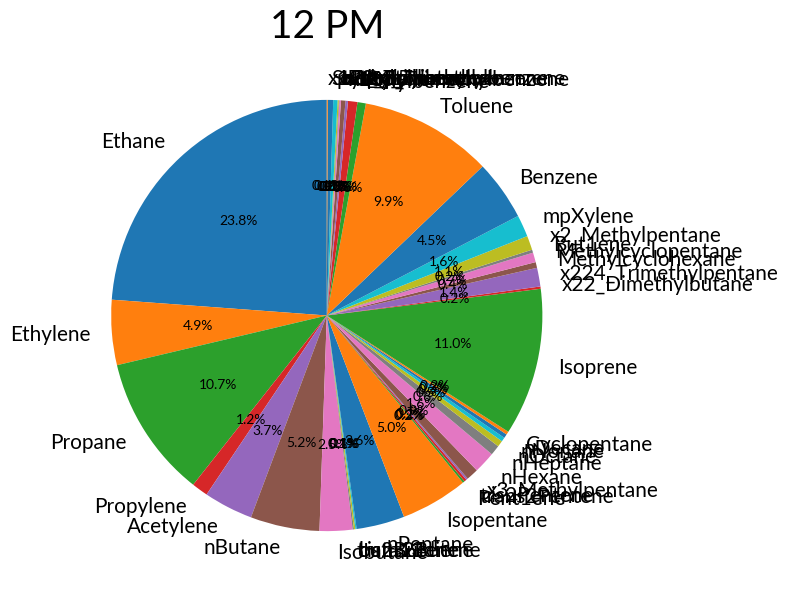

In [7]:
plt.figure(figsize=(7,7))
plt.pie(
    fractions_12,
    labels=fractions_12.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("12 PM")
plt.show()

In [8]:
print(fractions_12.sum(axis=0))

1.191158070701398


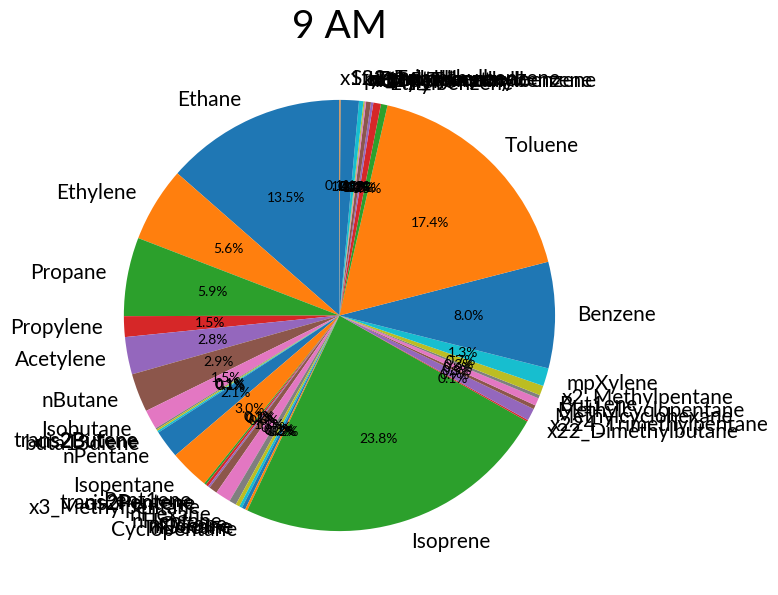

In [9]:
plt.figure(figsize=(7,7))
plt.pie(
    fractions_9,
    labels=fractions_9.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("9 AM")
plt.show()

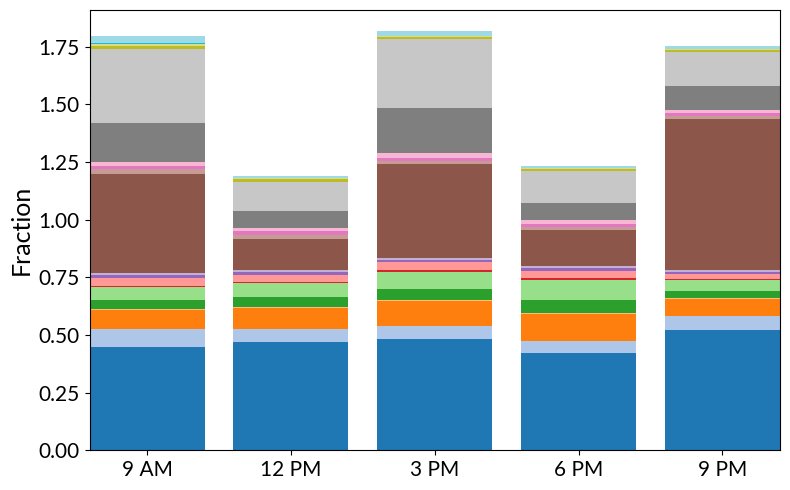

In [10]:
times_for_plot = ['9 AM', '12 PM', '3 PM', '6 PM', '9 PM']
ints_times_for_plot = [9, 12, 15, 18, 21]
df_plot = mean_per_hour.loc[ints_times_for_plot]

# Generate a color for each column
colors = plt.cm.tab20(np.linspace(0, 1, df_plot.shape[1]))

fig, ax = plt.subplots(figsize=(8, 5))

bottom = np.zeros(df_plot.shape[0])

for (col, color) in zip(df_plot.columns, colors):
    ax.bar(
        x=times_for_plot,
        height=df_plot[col],
        bottom=bottom,
        label=col,
        color=color
    )
    bottom += df_plot[col].values

ax.set_ylabel("Fraction")
#ax.set_title("Selected Times – 100% Stacked Bar Chart")
#plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

         Ethane  Ethylene    Propane  Propylene  Acetylene   nButane  \
hour                                                                   
0     27.982993  3.900876   9.728902   1.268908   2.620731  3.770993   
1      8.029521  0.942886   2.701558   0.279291   0.622063  0.869991   
2     31.061670  4.043920  10.854827   1.109690   2.783364  4.518641   
3      8.859707  0.763865   2.868405   0.210765   0.484086  0.985658   
4     31.513104  3.699139   9.372931   0.885253   2.769866  4.561463   
5      6.887029  0.956956   2.308399   0.182844   0.940376  0.805444   
6     28.983029  4.367730   9.592424   1.122504   2.700600  4.761303   
7      4.093668  0.936968   1.505412   0.258314   0.401419  0.825018   
8     23.181146  5.760246   8.273883   1.563185   2.948464  4.252924   
9      3.355304  1.391336   1.460304   0.384055   0.694114  0.717447   
10    23.424364  5.250010   8.796654   1.270838   3.107425  4.442897   
11     5.379792  1.306067   2.397432   0.321767   0.731114  1.08

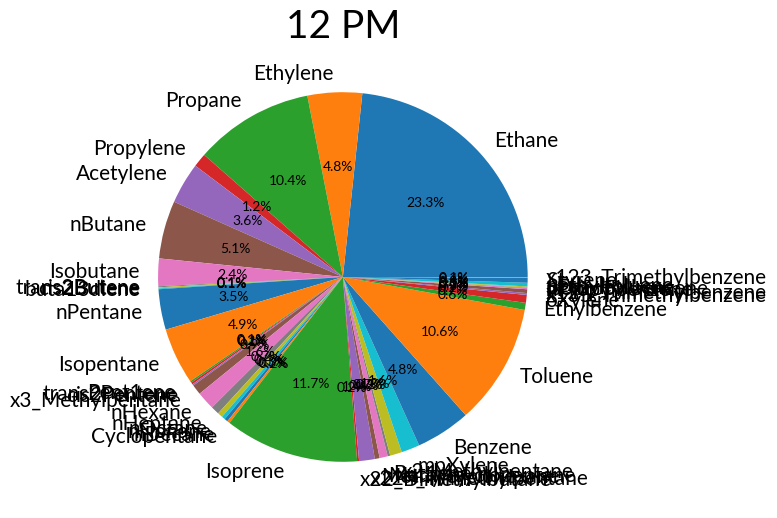

/tmp/ipykernel_1759101/1113606197.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


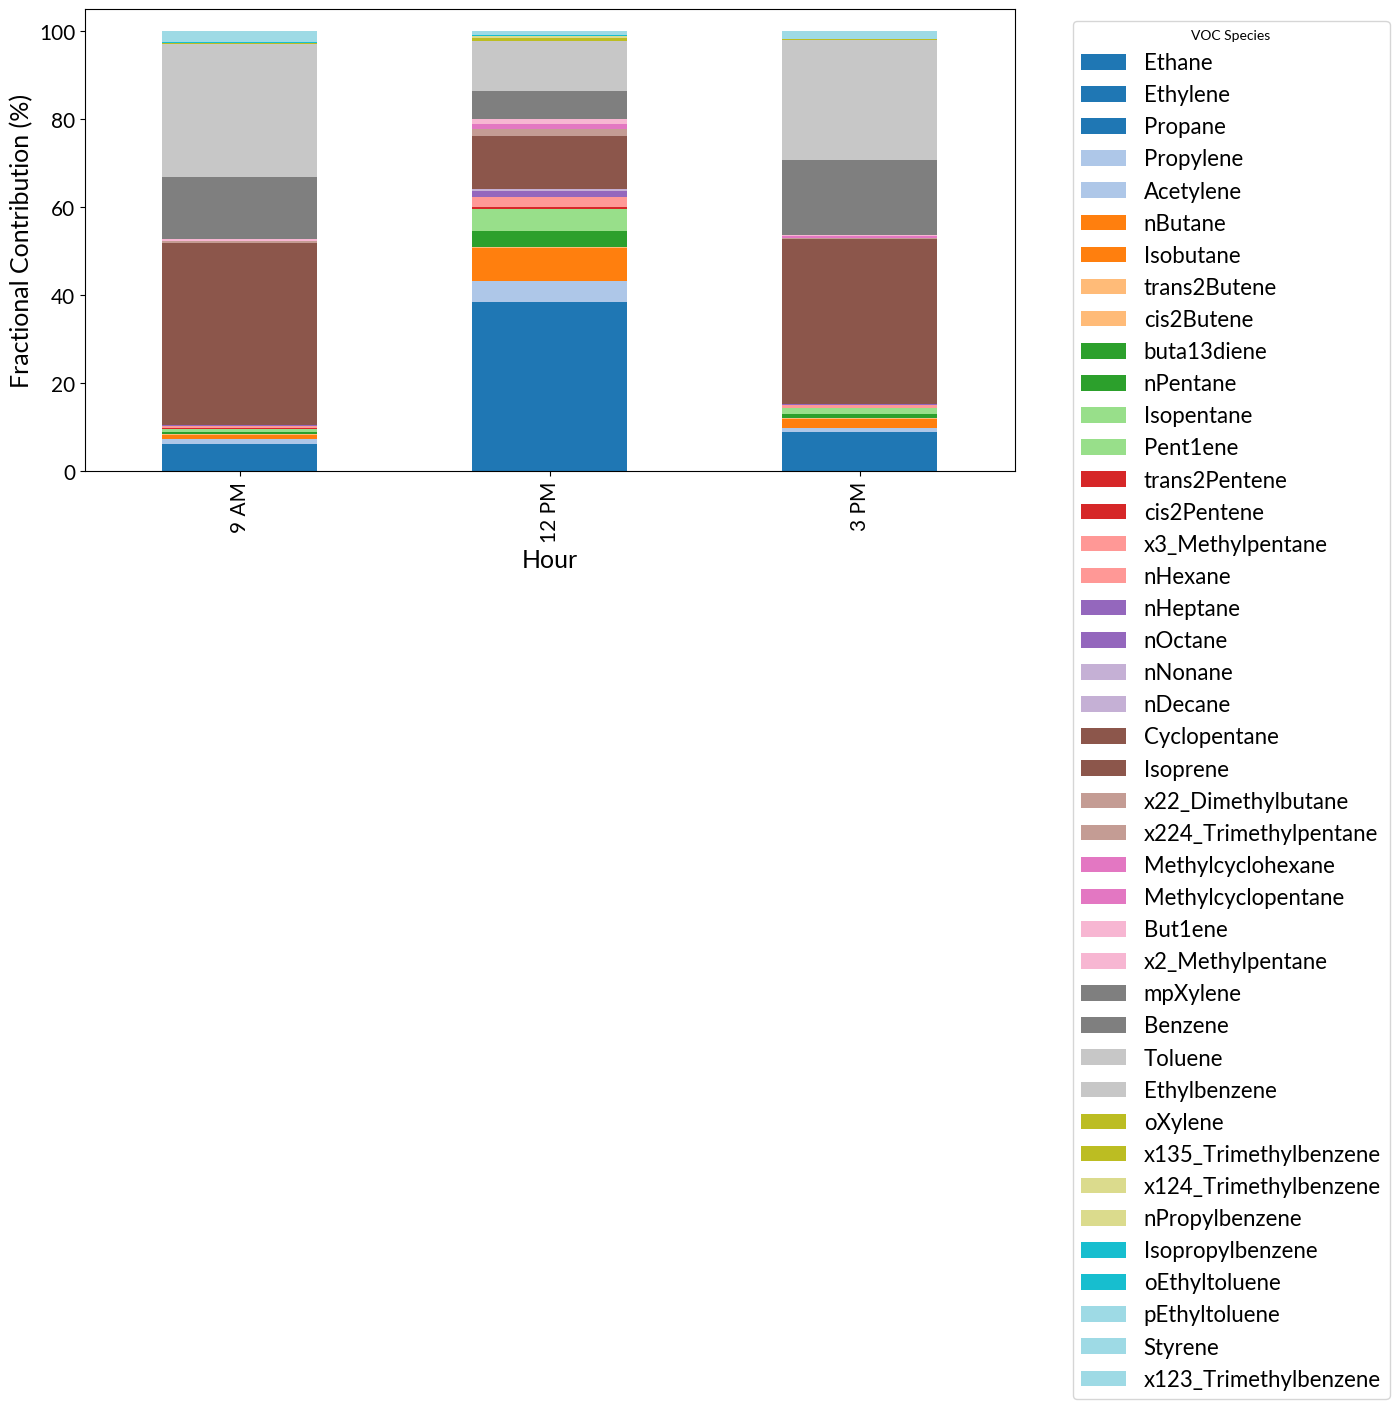

In [11]:
# Step 1: Resample to hourly sums
hourly_sum = df_ml_data.resample('h').sum()

# Step 2: Compute fractional contribution per hour
hourly_fraction = hourly_sum.div(hourly_sum.sum(axis=1), axis=0) * 100  # Percent

# # Step 3: Group by hour of the day and take the mean
hourly_fraction['hour'] = hourly_fraction.index.hour
mean_fraction_by_hour = hourly_fraction.groupby('hour').mean()
print(mean_fraction_by_hour)
# mean_fraction_by_hour.drop(columns='hour', inplace=True)

# Now mean_fraction_by_hour contains the average fractional contribution for each hour (0-23)

# Step 4: Pie chart example for 12 PM (hour = 12)
plt.figure(figsize=(6,6))
plt.pie(mean_fraction_by_hour.loc[12], labels=mean_fraction_by_hour.columns, autopct='%1.1f%%')
plt.title('12 PM')
plt.show()

# Step 5: Bar chart for 9 AM, 12 PM, 3 PM
hours_to_plot = [9, 12, 15]  # 9 AM, 12 PM, 3 PM
bar_data = mean_fraction_by_hour.loc[hours_to_plot]

# Plot
# Plot stacked bar chart
bar_data.plot(kind='bar', stacked=True, figsize=(12,6), colormap='tab20')
plt.xlabel('Hour')
plt.ylabel('Fractional Contribution (%)')
# plt.title('Average Fractional Contribution of Each Car at Selected Hours')
plt.xticks(ticks=range(len(hours_to_plot)), labels=['9 AM', '12 PM', '3 PM'])
plt.legend(title='VOC Species', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [12]:
ml_data = xr.open_dataset('/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/CampaignData_and_Merges/R0/CSL_MobileLab_Parked/merged/rev_1hr/all_CSL_MobileLab_Parked_rev1hr_iWASupdated.nc')
ml_data_vars_subset = ml_data[usos_vars]
df_ml_data = ml_data_vars_subset.to_dataframe()
df_ml_data.set_index('time_local', inplace=True)

udaq_voc_file = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/Hawthorne_data/data/hawthorne_udaq_all_vocs_hourly_timezone_carbon_number_updated.csv'
df_udaq_data = pd.read_csv(udaq_voc_file, index_col='time_local', parse_dates=True)

#Get only the data during the overlapping times
df_ml_data = df_ml_data.sort_index().loc['2024-07-15 12:00:00':'2024-08-18 18:00:00']
df_udaq_data = df_udaq_data.sort_index().loc['2024-07-15 12:00:00':'2024-08-18 18:00:00']

#Map the same species in ML and UDAQ data
mapping = dict(zip(df_mapping_parameters['USOS Mapping'], df_mapping_parameters['UDAQ_Variable']))
#print(mapping)


In [13]:
#Turn any negatives into NaNs
for spec in df_ml_data.columns:
    df_ml_data[spec] = df_ml_data[spec].mask(df_ml_data[spec] < 0, np.nan)

#Rename columns to a more common name by using the mappings
df_ml_data.columns = [
    mapping.get(col) if not pd.isna(col) else mapping.get(np.nan, col)
    for col in df_ml_data.columns
]

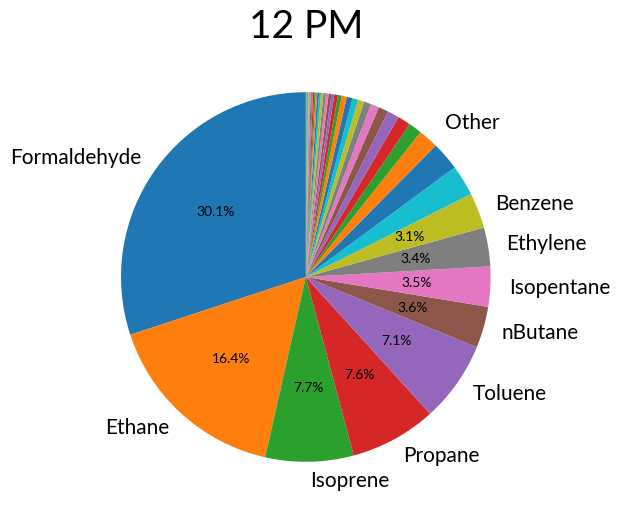

In [14]:
# Step 1: Resample to hourly sums
hourly_sum = df_ml_data.resample('h').sum()

# Step 2: Compute fractional contribution per hour
hourly_fraction = hourly_sum.div(hourly_sum.sum(axis=1), axis=0) * 100  # Percent

# # Step 3: Group by hour of the day and take the mean
hourly_fraction['hour'] = hourly_fraction.index.hour
mean_fraction_by_hour = hourly_fraction.groupby('hour').mean()
# mean_fraction_by_hour.drop(columns='hour', inplace=True)

# Get the contributions for 12 PM (or any hour)
contributions = mean_fraction_by_hour.loc[12]
# Sort from largest to smallest
contributions_sorted = contributions.sort_values(ascending=False)

# Now mean_fraction_by_hour contains the average fractional contribution for each hour (0-23)
# Set threshold
threshold = 3

# Create labels: only show car names if contribution >= threshold, else empty string
labels = [car if val >= threshold else '' for car, val in zip(contributions_sorted.index, contributions_sorted)]

# Custom autopct function
def autopct_threshold(pct, threshold=3):
    return f'{pct:.1f}%' if pct >= threshold else ''  # Show label only if >= threshold

plt.figure(figsize=(6,6))
plt.pie(
    contributions_sorted,
    labels=labels,
    autopct=lambda pct: autopct_threshold(pct, threshold=3),
    startangle=90
)

# Add a single 'Other' annotation
plt.annotate(
    'Other', 
    xy=(0, 0),  # Center of the pie chart
    xytext=(0.9, 0.8),  # Position text below the pie
    ha='center', 
    fontsize=15
)
plt.title('12 PM')
plt.show()

In [15]:
# Step 1: Resample to hourly sums
hourly_sum = df_ml_data.resample('h').sum()

# Step 2: Compute fractional contribution per hour
hourly_fraction = hourly_sum.div(hourly_sum.sum(axis=1), axis=0) * 100  # Percent

# # Step 3: Group by hour of the day and take the mean
hourly_fraction['hour'] = hourly_fraction.index.hour
mean_fraction_by_hour = hourly_fraction.groupby('hour').mean()
# mean_fraction_by_hour.drop(columns='hour', inplace=True)

hours_to_plot = [6, 9, 12, 15, 18, 21]
times_for_plot = ['6 AM', '9 AM', '12 PM', '3 PM', '6 PM', '9 PM']
df_plot = mean_fraction_by_hour.loc[hours_to_plot]

print(df_plot)
# # Sort from largest to smallest
# df_plot_sorted = df_plot.sort_values(by=df_plot.columns, ascending=False)
# print(df_plot_sorted)


         Ethane  Ethylene   Propane  Propylene  Acetylene   nButane  \
hour                                                                  
6     24.702132  3.709694  8.170397   0.957515   2.298380  4.140010   
9      2.513960  1.040663  1.085908   0.289160   0.519648  0.534521   
12    16.404761  3.398063  7.563964   0.878219   2.694448  3.608668   
15     3.385198  0.738608  1.311317   0.202330   0.384130  0.839464   
18    16.421343  3.560942  6.610460   1.112392   2.211753  5.102031   
21     4.856048  1.041089  1.508096   0.312547   0.581863  0.702692   

      Isobutane  trans2Butene  cis2Butene  buta13diene  ...  Ethylbenzene  \
hour                                                    ...                 
6      1.948876      0.114922    0.122413     0.074296  ...      0.338921   
9      0.268888      0.020863    0.022811     0.025763  ...      0.091146   
12     1.746568      0.066211    0.067735     0.052812  ...      0.444612   
15     0.417713      0.025296    0.026723     

In [99]:
#print(df_plot)
series_list = []
for idx, row in df_plot.iterrows():
    row_sorted = row.sort_values(ascending=False)
    display_labels = []
    other_series = pd.Series([0], index = ['Other'])
    row_sorted_with_other = pd.concat([row_sorted, other_series])
    #print(row_sorted_with_other) #This gives us a pandas series with index as the species and value as its fractional contribution, one for each hour at 6 AM, 9 AM, etc in 3 hour intervals
    
    for val, col in zip(row_sorted_with_other.values, row_sorted_with_other.index):
        #Go through all the values in these dataseries
        #If it is less than the threshold and not in the other category, add the label to display_labels
        if val >= threshold and col != 'Other' :
            display_labels.append(col)
            #total_percentages_excluding_other.append(val)
        #If the value is less than 3% contribution to the total VOCs, then add sum it into the Other category, replace the Other value with it, and remove the species from the Series index
        elif val < threshold and col != 'Other':
            spec_plus_other = row_sorted_with_other.loc[col] + row_sorted_with_other.loc['Other']
            #print(spec_plus_other)
            row_sorted_with_other = row_sorted_with_other.replace(row_sorted_with_other.loc['Other'], spec_plus_other)
            row_sorted_with_other = row_sorted_with_other.drop(col)
        else:
            display_labels.append('')  # hide small slice
        #This loop will complete for Series 1, which represents the full series for 6 AM then go on to altering 9 AM, then 12 PM.
    
    #print(row_sorted_with_other)
    series_list.append(row_sorted_with_other)
#print(series_list)
all_species = pd.Index([])

for s in series_list:
    all_species = all_species.union(s.index)

#print(all_species)

# hues = np.linspace(0, 1, 11, endpoint=False)
# colors_list = [mcolors.hsv_to_rgb([h, 0.3, 0.95]) for h in hues]
cmap = plt.get_cmap("tab10")
colors_list = [cmap(i) for i in range(11)]

# Map each column to a color
colors_dict = {col: color for col, color in zip(all_species, colors_list)}
print(colors_dict)

{'Benzene': (np.float64(0.12156862745098039), np.float64(0.4666666666666667), np.float64(0.7058823529411765), np.float64(1.0)), 'Ethane': (np.float64(1.0), np.float64(0.4980392156862745), np.float64(0.054901960784313725), np.float64(1.0)), 'Ethylene': (np.float64(0.17254901960784313), np.float64(0.6274509803921569), np.float64(0.17254901960784313), np.float64(1.0)), 'Formaldehyde': (np.float64(0.8392156862745098), np.float64(0.15294117647058825), np.float64(0.1568627450980392), np.float64(1.0)), 'Isopentane': (np.float64(0.5803921568627451), np.float64(0.403921568627451), np.float64(0.7411764705882353), np.float64(1.0)), 'Isoprene': (np.float64(0.5490196078431373), np.float64(0.33725490196078434), np.float64(0.29411764705882354), np.float64(1.0)), 'Other': (np.float64(0.8901960784313725), np.float64(0.4666666666666667), np.float64(0.7607843137254902), np.float64(1.0)), 'Propane': (np.float64(0.4980392156862745), np.float64(0.4980392156862745), np.float64(0.4980392156862745), np.float64

['Ethane', 'Formaldehyde', 'Toluene', 'Propane', 'Isoprene', 'Isopentane', 'nButane', 'Ethylene', 'Benzene', 'Other']
['Formaldehyde', 'Isoprene', 'Toluene', 'Benzene', 'Other']
['Formaldehyde', 'Ethane', 'Isoprene', 'Propane', 'Toluene', 'nButane', 'Isopentane', 'Ethylene', 'Benzene', 'Other']
['Formaldehyde', 'Isoprene', 'Toluene', 'Benzene', 'Ethane', 'Other']
['Formaldehyde', 'Ethane', 'Isoprene', 'Toluene', 'Propane', 'Isopentane', 'nButane', 'Benzene', 'nPentane', 'Ethylene', 'Other']
['Isoprene', 'Formaldehyde', 'Toluene', 'Benzene', 'Ethane', 'Other']


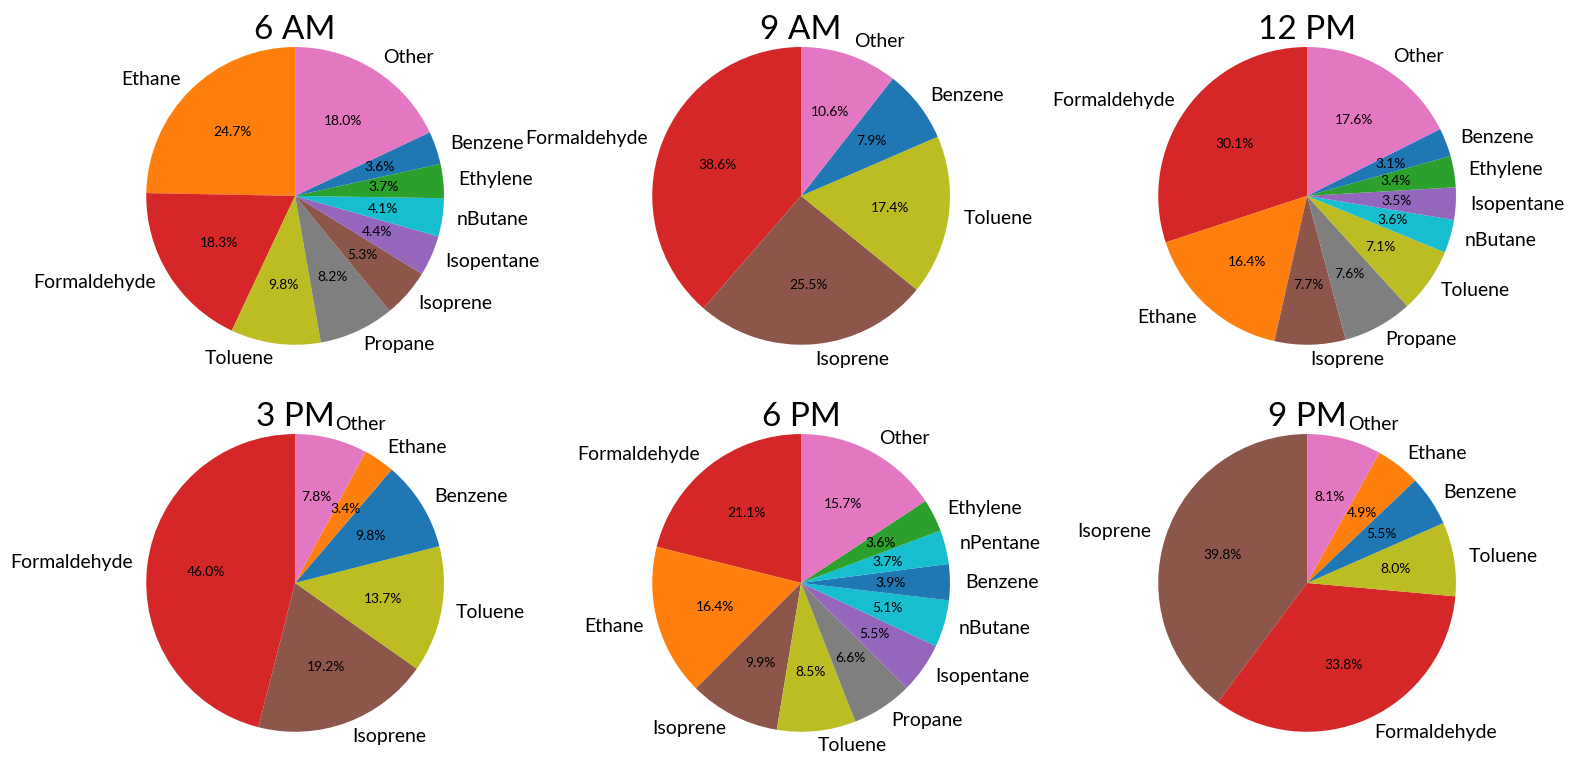

In [101]:
fig, axes = plt.subplots(2,3, figsize=(16, 8), constrained_layout=False)

# Adjust spacing between subplots
plt.subplots_adjust(
    left=0.05,    # space on left of figure
    right=0.97,   # space on right of figure
    top=0.95,     # space at top
    bottom=0.001,  # space at bottom
    wspace=0.1,   # horizontal space between subplots
    hspace=0.04    # vertical space between subplots
)

axes = axes.flatten()
threshold = 3  # percentage threshold

# hues = np.linspace(0, 1, 11, endpoint=False)
# colors_list = [mcolors.hsv_to_rgb([h, 0.4, 0.9]) for h in hues]

# # Map each column to a color
# colors_dict = {col: color for col, color in zip(mean_fraction_by_hour.columns, colors_list)}


# for idx, row in df_plot.iterrows():
#     row_sorted = row.sort_values(ascending=False)
#     display_labels = []
#     other_series = pd.Series([0], index = ['Other'])
#     row_sorted_with_other = pd.concat([row_sorted, other_series])

#     for val, col in zip(row_sorted_with_other.values, row_sorted_with_other.index):
#         if val >= threshold and col != 'Other' :
#             display_labels.append(col)
#             #total_percentages_excluding_other.append(val)
#         elif val < threshold and col != 'Other':
#             spec_plus_other = row_sorted_with_other.loc[col] + row_sorted_with_other.loc['Other']
#             #print(spec_plus_other)
#             row_sorted_with_other = row_sorted_with_other.replace(row_sorted_with_other.loc['Other'], spec_plus_other)
#             row_sorted_with_other = row_sorted_with_other.drop(col)
#         else:
#             display_labels.append('')  # hide small slice


for ax, (idx, row), label in zip(axes, df_plot.iterrows(),  times_for_plot):
    # # Predefine a color for each column
    # cmap = plt.get_cmap('tab20')  # or any other colormap
    # colors_dict = {col: cmap(i / len(df_plot.columns)) for i, col in enumerate(df_plot.columns)}
    row_sorted = row.sort_values(ascending=False)
    #print(row_sorted)

 # Prepare labels: hide if percentage < threshold
    display_labels = []
    # total_percentages_excluding_other = []
    #print(row_sorted.index)
    other_series = pd.Series([0], index = ['Other'])
    row_sorted_with_other = pd.concat([row_sorted, other_series])
    #print(row_sorted_with_other.index)
    for val, col in zip(row_sorted_with_other.values, row_sorted_with_other.index):
        if val >= threshold and col != 'Other' :
            display_labels.append(col)
            #total_percentages_excluding_other.append(val)
        elif val < threshold and col != 'Other':
            spec_plus_other = row_sorted_with_other.loc[col] + row_sorted_with_other.loc['Other']
            #print(spec_plus_other)
            row_sorted_with_other = row_sorted_with_other.replace(row_sorted_with_other.loc['Other'], spec_plus_other)
            row_sorted_with_other = row_sorted_with_other.drop(col)
        else:
            display_labels.append('Other')  # hide small slice

    print(display_labels)
            
    # total_percentages_excluding_other = np.array(total_percentages_excluding_other)
    # sum_percentages_excluding_other = np.sum(total_percentages_excluding_other)
    # other_percentage = round(100-sum_percentages_excluding_other, ndigits=1)
    # print(other_percentage)
    
    # Prepare colors: match the column name
    row_colors = [colors_dict[col] for col in row_sorted_with_other.index]
    
    # autopct function: hide percentages < threshold
    autopct = lambda pct: f'{pct:.1f}%' if pct >= threshold else ''

    wedges, texts, autotexts = ax.pie(
        row_sorted_with_other,
        labels=display_labels,
        colors=row_colors,
        autopct=autopct,
        startangle=90
    )

    # Outer labels (display_labels)
    for text in texts:
        text.set_fontsize(14)  # adjust outer labels size

    # Percentages inside slices
    for autotext in autotexts:
        autotext.set_fontsize(10)  # adjust percentages size
    
    ax.set_title(label, y=0.9, fontsize = 24)

    # ax.annotate(
    #     'Other', 
    #     xy=(0, 0),  # Center of the pie chart
    #     xytext=(0.48, 0.97),  # Position text around the pie
    #     ha='center', 
    #     fontsize=14
    # )
    # ax.annotate(
    #     str(other_percentage) + '%', 
    #     xy=(0, 0),  # Center of the pie chart
    #     xytext=(0.4, 0.6),  # Position text around the pie
    #     ha='center', 
    #     fontsize=10
    # )



# # Hide unused axes
# for ax in axes[n_charts:]:
#     ax.axis('off')

plt.savefig(dirpath + '/UDAQ_reports/q1_report/plots/mobilelab_voc_speciation.png', dpi =300)
plt.show()

/tmp/ipykernel_1759101/972455219.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


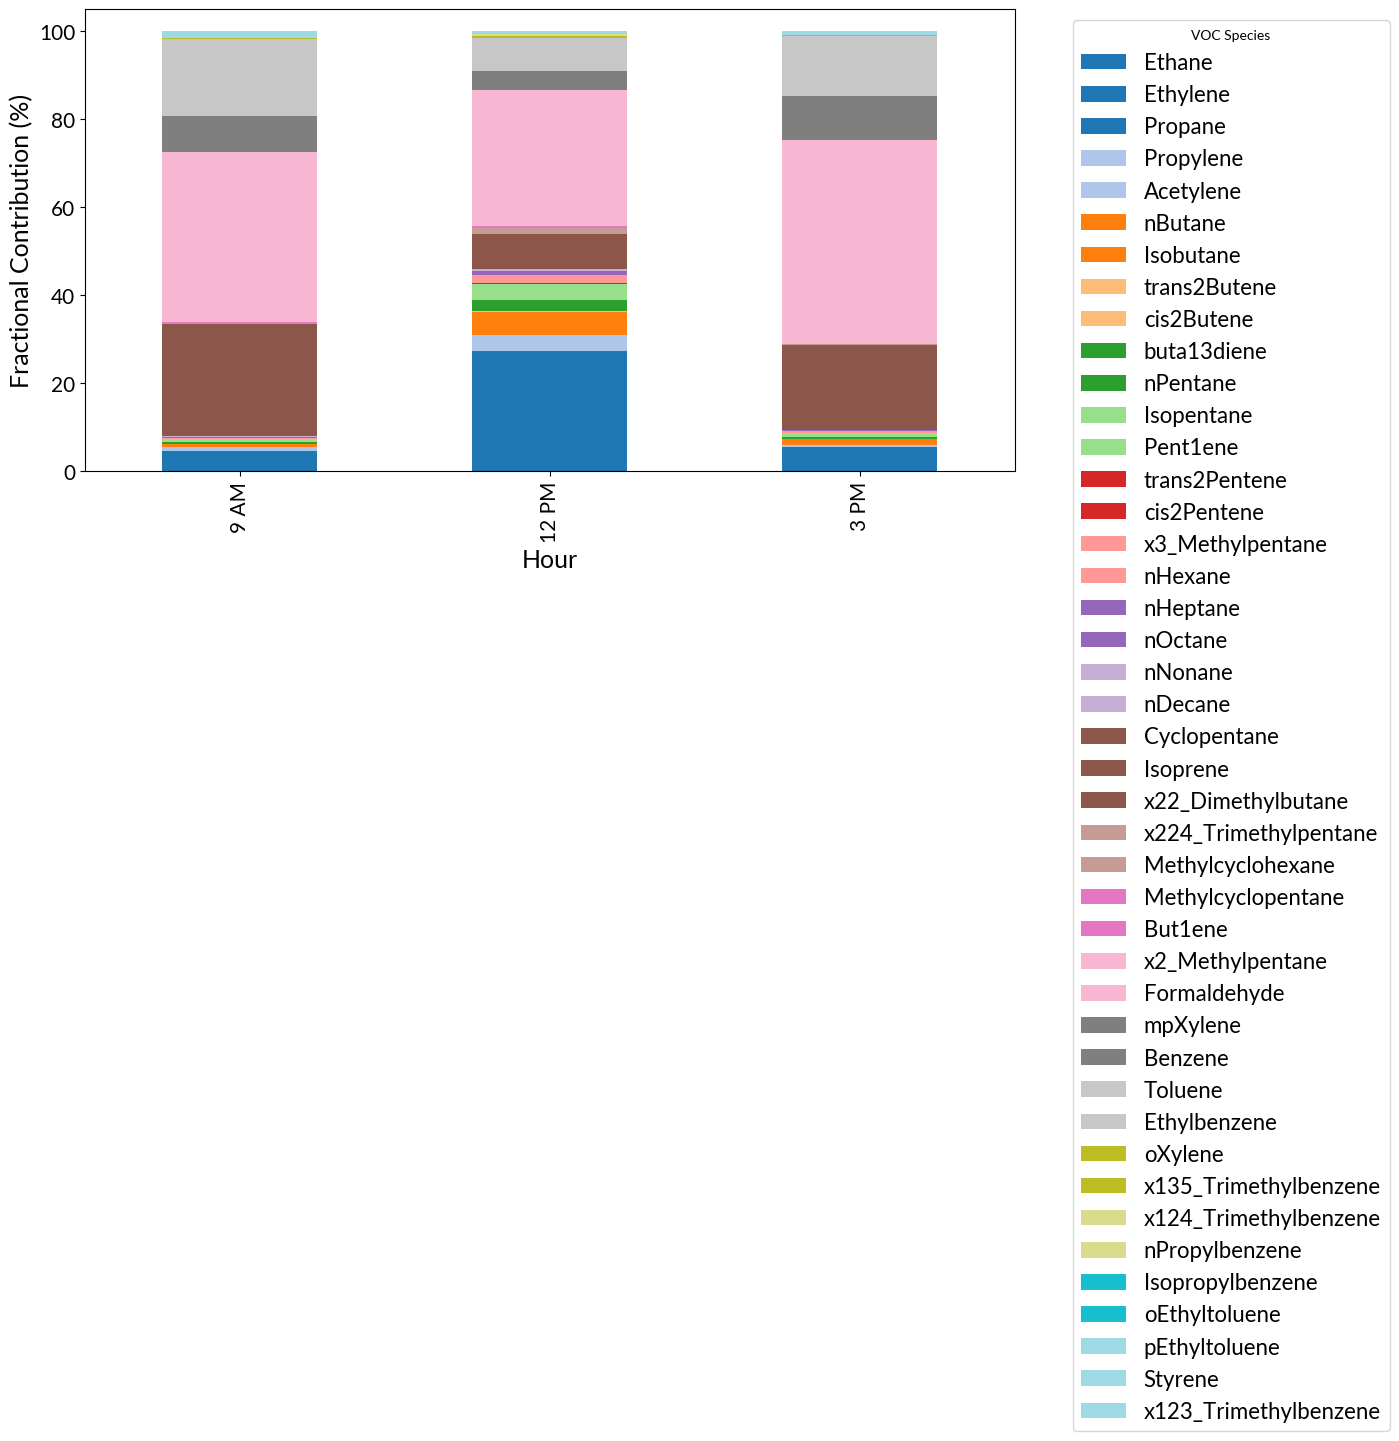

In [17]:

# Step 5: Bar chart for 9 AM, 12 PM, 3 PM
hours_to_plot = [9, 12, 15]  # 9 AM, 12 PM, 3 PM
bar_data = mean_fraction_by_hour.loc[hours_to_plot]

# Plot
# Plot stacked bar chart
bar_data.plot(kind='bar', stacked=True, figsize=(12,6), colormap='tab20')
plt.xlabel('Hour')
plt.ylabel('Fractional Contribution (%)')
# plt.title('Average Fractional Contribution of Each Car at Selected Hours')
plt.xticks(ticks=range(len(hours_to_plot)), labels=['9 AM', '12 PM', '3 PM'])
plt.legend(title='VOC Species', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()